In [38]:
#imported the essential libraries for Eda and data preprocessing
import pandas as pd 
import numpy as np
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_curve, auc
import optuna 

In [2]:
#reading the files and extrcting the inner files from one large file
xls = pd.ExcelFile("Customer_Churn_Data_Large.xlsx")
print(xls.sheet_names)

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [3]:
#converting the differnt inner files into dataframe
df_Customer_Demo = xls.parse('Customer_Demographics')
df_Transaction = xls.parse('Transaction_History')
df_Customer_service = xls.parse('Customer_Service')
df_Online_activity = xls.parse('Online_Activity')
df_Churn = xls.parse('Churn_Status')


In [4]:
#merging the different dataframe into single dataframe
df = df_Customer_Demo.merge(df_Transaction, on = 'CustomerID', how = 'inner')\
     .merge(df_Customer_service,  on = 'CustomerID', how = 'inner')\
     .merge(df_Online_activity, on = 'CustomerID', how = 'inner')\
     .merge(df_Churn, on = 'CustomerID', how = 'inner')

df

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5199,995,23,F,Divorced,Low,1236,2022-03-19,225.82,Furniture,9101,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1
5200,995,23,F,Divorced,Low,6933,2022-08-30,494.90,Groceries,9101,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1
5201,995,23,F,Divorced,Low,4405,2022-10-23,101.21,Clothing,9101,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1
5202,995,23,F,Divorced,Low,8667,2022-10-18,73.91,Clothing,9101,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1


In [5]:
#rearranging the columns
col = df.pop('TransactionID')
df.insert(1, 'TransactionID', col)
col1 = df.pop('InteractionID')
df.insert(2, 'InteractionID', col1)
df

,CustomerID,TransactionID,InteractionID,Age,Gender,MaritalStatus,IncomeLevel,TransactionDate,AmountSpent,ProductCategory,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,7194,6363,62,M,Single,Low,2022-03-27,416.50,Electronics,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,7250,3329,65,M,Married,Low,2022-08-08,54.96,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,9660,3329,65,M,Married,Low,2022-07-25,197.50,Electronics,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,2998,3329,65,M,Married,Low,2022-01-25,101.31,Furniture,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,1228,3329,65,M,Married,Low,2022-07-24,397.37,Clothing,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5199,995,1236,9101,23,F,Divorced,Low,2022-03-19,225.82,Furniture,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1
5200,995,6933,9101,23,F,Divorced,Low,2022-08-30,494.90,Groceries,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1
5201,995,4405,9101,23,F,Divorced,Low,2022-10-23,101.21,Clothing,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1
5202,995,8667,9101,23,F,Divorced,Low,2022-10-18,73.91,Clothing,2022-05-02,Inquiry,Resolved,2023-07-31,34,Website,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   TransactionID     5204 non-null   int64         
 2   InteractionID     5204 non-null   int64         
 3   Age               5204 non-null   int64         
 4   Gender            5204 non-null   object        
 5   MaritalStatus     5204 non-null   object        
 6   IncomeLevel       5204 non-null   object        
 7   TransactionDate   5204 non-null   datetime64[ns]
 8   AmountSpent       5204 non-null   float64       
 9   ProductCategory   5204 non-null   object        
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   object        
 12  ResolutionStatus  5204 non-null   object        
 13  LastLoginDate     5204 non-null   datetime64[ns]
 14  LoginFrequency    5204 n

In [7]:
#Checking the null values
df.isnull().sum()

CustomerID          0
TransactionID       0
InteractionID       0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

In [8]:
df.describe()


,CustomerID,TransactionID,InteractionID,Age,TransactionDate,AmountSpent,InteractionDate,LastLoginDate,LoginFrequency,ChurnStatus
count,5204.000000,5204.000000,5204.000000,5204.000000,5204,5204.000000,5204,5204,5204.000000,5204.000000
mean,496.470407,5495.988470,5921.861261,43.140085,2022-06-29 08:30:15.219062272,254.354940,2022-07-01 16:31:10.561106944,2023-07-04 09:27:31.960030720,25.918332,0.205995
min,1.000000,1000.000000,2015.000000,18.000000,2022-01-01 00:00:00,5.180000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000,0.000000
25%,244.000000,3218.000000,3873.250000,29.000000,2022-03-30 00:00:00,128.940000,2022-04-07 00:00:00,2023-04-04 00:00:00,14.000000,0.000000
50%,504.000000,5490.000000,5903.000000,43.000000,2022-06-27 00:00:00,255.175000,2022-07-02 00:00:00,2023-07-11 00:00:00,27.000000,0.000000
75%,743.000000,7713.000000,7851.000000,57.000000,2022-09-28 00:00:00,378.605000,2022-09-25 00:00:00,2023-10-01 00:00:00,38.000000,0.000000
max,995.000000,9997.000000,9997.000000,69.000000,2022-12-31 00:00:00,499.700000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000,1.000000
std,286.681289,2595.575295,2332.331260,15.430343,NaN,143.329654,NaN,NaN,14.110627,0.404466


In [9]:
#converting the columns into datetime objects and extracting out the days

df1 = df.copy()
df1['TransactionDate'] = pd.to_datetime(df1['TransactionDate'])
df1['InteractionDate'] = pd.to_datetime(df1['InteractionDate'])
df1['LastLoginDate'] = pd.to_datetime(df1['LastLoginDate'])

reference_date = max(
    df1['TransactionDate'].max(),
    df1['InteractionDate'].max(),
    df1['LastLoginDate'].max() )

df1['DaysSinceTransaction'] = (reference_date - df1['TransactionDate']).dt.days
df1['DaysSinceInteraction'] = (reference_date - df1['InteractionDate']).dt.days
df1['DaysSinceLogin'] = (reference_date - df1['LastLoginDate']).dt.days.abs()
df1.drop(['TransactionDate', 'InteractionDate', 'LastLoginDate'], axis=1, inplace=True)


col = df1.pop('DaysSinceTransaction')
df1.insert(13, 'DaysSinceTransaction', col)
col1 = df1.pop('DaysSinceInteraction')
df1.insert(14, 'DaysSinceInteraction', col1)
col2 = df1.pop('DaysSinceLogin')
df1.insert(15, 'DaysSinceLogin', col2)
df1

,CustomerID,TransactionID,InteractionID,Age,Gender,...,ServiceUsage,DaysSinceTransaction,DaysSinceInteraction,DaysSinceLogin,ChurnStatus
0,1,7194,6363,62,M,...,Mobile App,644,640,71,0
1,2,7250,3329,65,M,...,Website,510,654,26,1
2,2,9660,3329,65,M,...,Website,524,654,26,1
3,2,2998,3329,65,M,...,Website,705,654,26,1
4,2,1228,3329,65,M,...,Website,525,654,26,1
...,...,...,...,...,...,...,...,...,...,...,...
5199,995,1236,9101,23,F,...,Website,652,608,153,1
5200,995,6933,9101,23,F,...,Website,488,608,153,1
5201,995,4405,9101,23,F,...,Website,434,608,153,1
5202,995,8667,9101,23,F,...,Website,439,608,153,1


In [10]:
df1.describe()

,CustomerID,TransactionID,InteractionID,Age,AmountSpent,LoginFrequency,DaysSinceTransaction,DaysSinceInteraction,DaysSinceLogin,ChurnStatus
count,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000,5204.000000
mean,496.470407,5495.988470,5921.861261,43.140085,254.354940,25.918332,549.645657,547.311683,179.605880,0.205995
std,286.681289,2595.575295,2332.331260,15.430343,143.329654,14.110627,104.499742,102.388679,104.509383,0.404466
min,1.000000,1000.000000,2015.000000,18.000000,5.180000,1.000000,365.000000,366.000000,0.000000,0.000000
25%,244.000000,3218.000000,3873.250000,29.000000,128.940000,14.000000,459.000000,462.000000,91.000000,0.000000
50%,504.000000,5490.000000,5903.000000,43.000000,255.175000,27.000000,552.000000,547.000000,173.000000,0.000000
75%,743.000000,7713.000000,7851.000000,57.000000,378.605000,38.000000,641.000000,633.000000,271.000000,0.000000
max,995.000000,9997.000000,9997.000000,69.000000,499.700000,49.000000,729.000000,729.000000,364.000000,1.000000


In [11]:
columns = ['ResolutionStatus', 'IncomeLevel', 'MaritalStatus', 'ProductCategory']

for column in columns:
    print(df1[column].value_counts())

ResolutionStatus
Resolved      2693
Unresolved    2511
Name: count, dtype: int64
IncomeLevel
Medium    1800
Low       1705
High      1699
Name: count, dtype: int64
MaritalStatus
Divorced    1425
Widowed     1405
Single      1209
Married     1165
Name: count, dtype: int64
ProductCategory
Electronics    1074
Books          1070
Clothing       1030
Groceries      1025
Furniture      1005
Name: count, dtype: int64


In [12]:
#applying the label encoding to the columns

df2 = df1.copy()
columns = ['Gender', 'MaritalStatus', 'ProductCategory', 'InteractionType', 'ServiceUsage']
le = LabelEncoder()

for col in columns:
    df2[col] = le.fit_transform(df2[col])

income_order = {'Low': 1, 'Medium': 2, 'High': 3}
resolution_order = {'Resolved':1, 'Unresolved': 0}

df2['ResolutionStatus'] = df2['ResolutionStatus'].map(resolution_order)
df2['IncomeLevel'] = df2['IncomeLevel'].map(income_order)


In [13]:
df2.duplicated().sum()

0

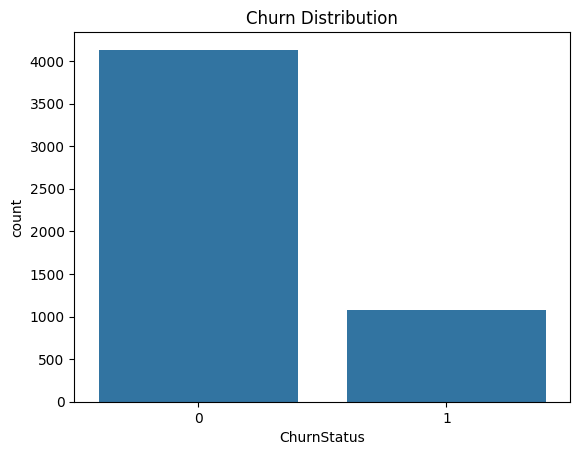

In [14]:
# frome here visualizing the data and performing EDA
sns.countplot(x='ChurnStatus', data=df2)
plt.title("Churn Distribution")
plt.show()

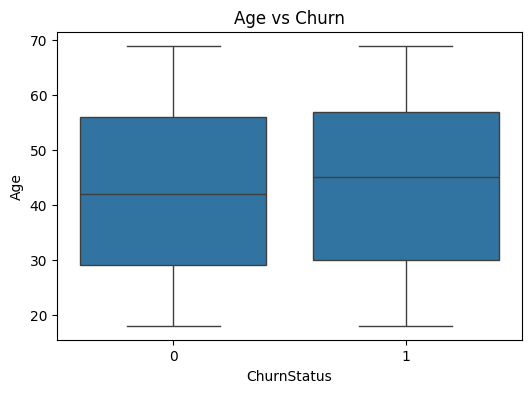

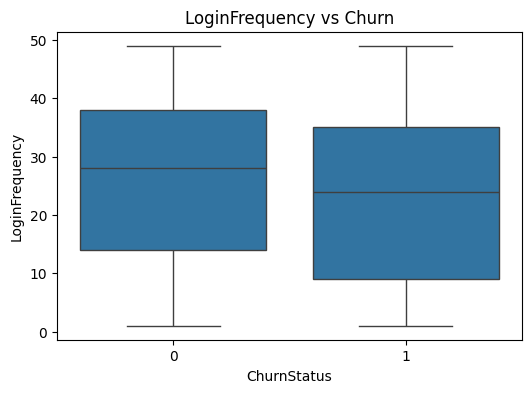

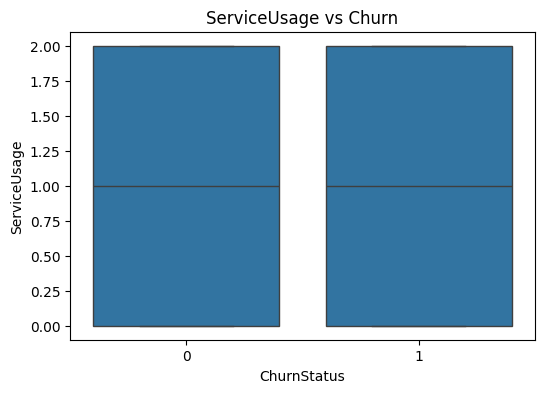

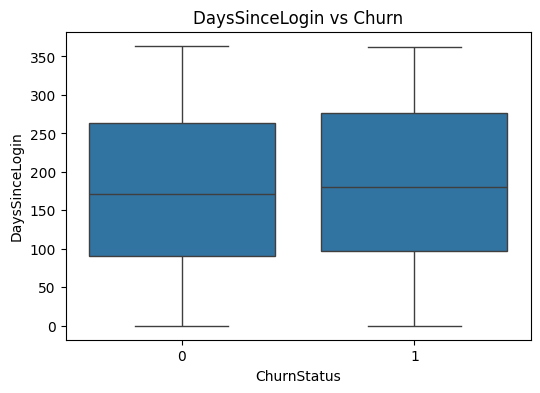

In [15]:
numerical_cols = ['Age', 'LoginFrequency', 'ServiceUsage', 'DaysSinceLogin']  

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='ChurnStatus', y=col, data=df2)
    plt.title(f"{col} vs Churn")
    plt.show()

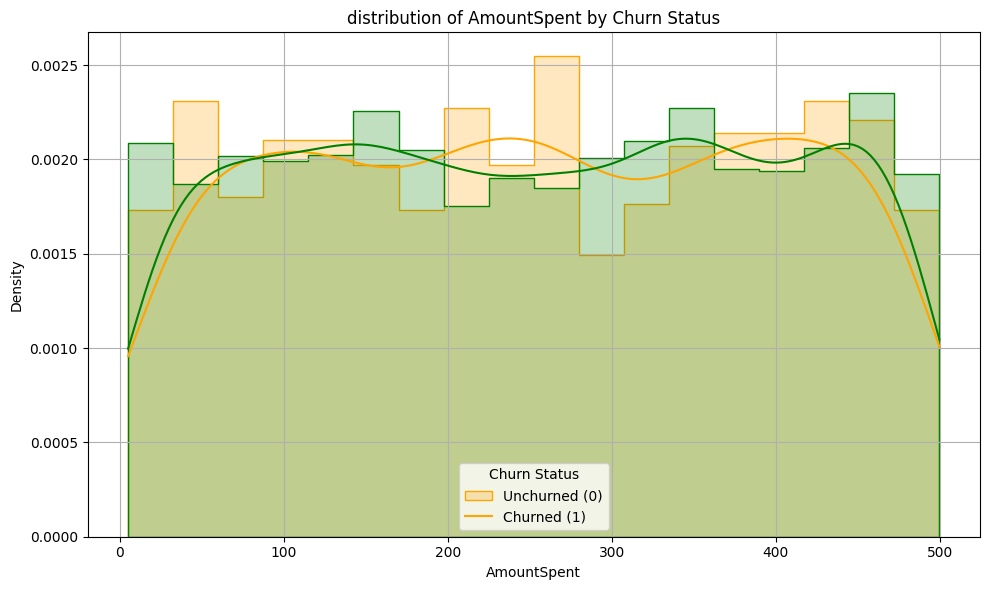

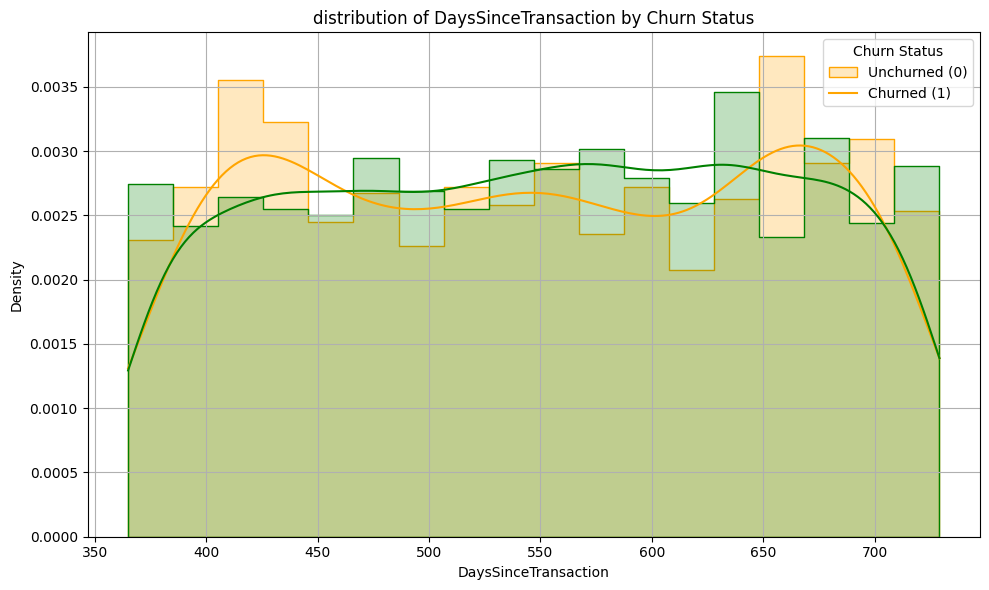

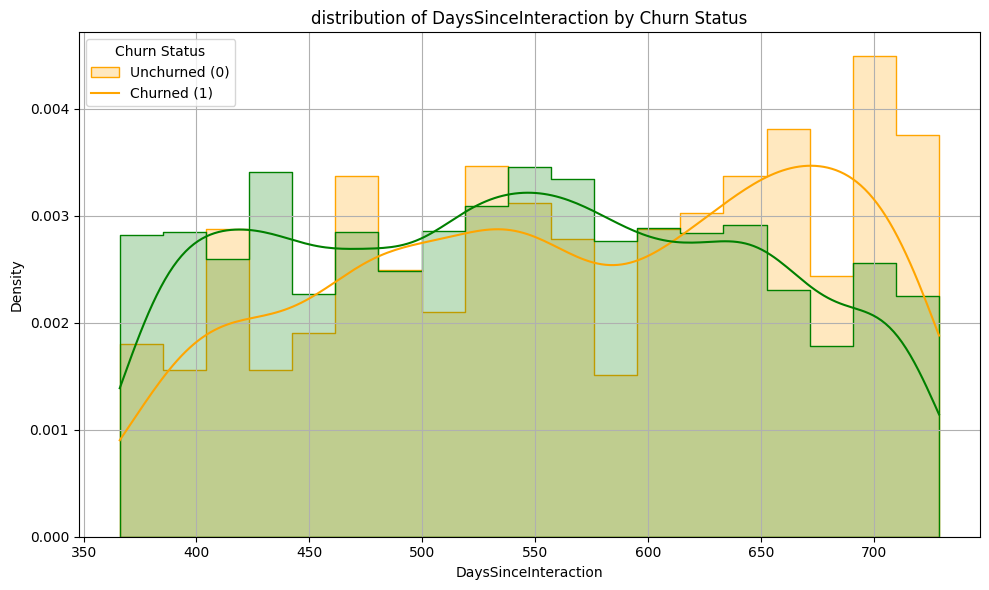

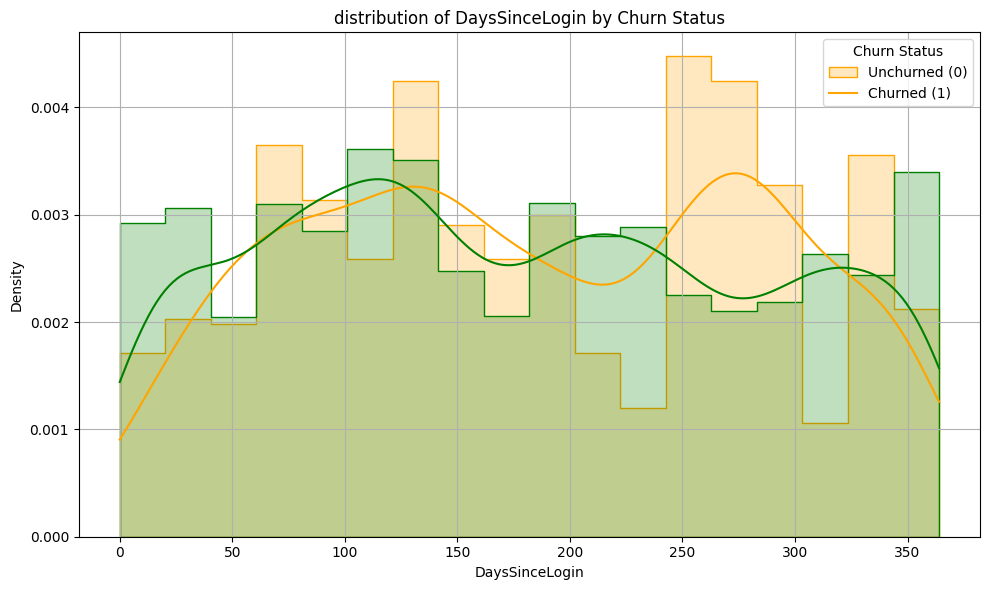

In [16]:
columns = ['AmountSpent', 'DaysSinceTransaction', 'DaysSinceInteraction', 'DaysSinceLogin']
for col in columns:
    palette = {0: 'green', 1: 'orange'}
    plt.figure(figsize=(10, 6))
    sns.histplot(data = df2, x = col, hue = 'ChurnStatus',kde=True,element='step',stat='density', common_norm=False,palette=palette)
    plt.title(f'distribution of {col} by Churn Status')
    plt.xlabel(f'{col}')
    plt.ylabel("Density")
    plt.legend(title='Churn Status', labels=['Unchurned (0)', 'Churned (1)'])
    plt.grid(True)
    plt.tight_layout()

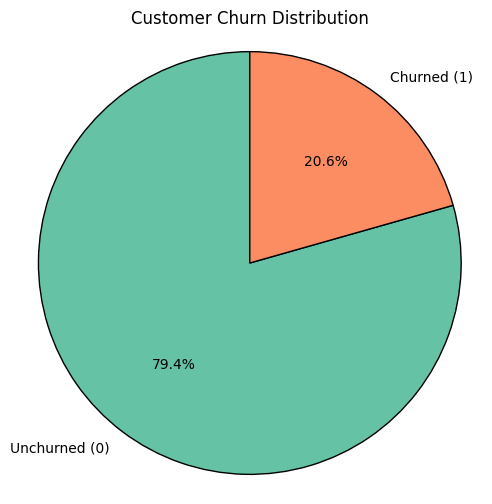

In [17]:
churn_counts = df2['ChurnStatus'].value_counts()
labels = ['Unchurned (0)', 'Churned (1)']
colors = ['#66c2a5', '#fc8d62']



plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts,
    labels=labels,
    autopct='%1.1f%%',     
    startangle=90,         
    colors=colors,
    wedgeprops={'edgecolor': 'black'}  
)
plt.title('Customer Churn Distribution')
plt.axis('equal')  
plt.show()

In [18]:
df2['ChurnStatus'].value_counts()

ChurnStatus
0    4132
1    1072
Name: count, dtype: int64

In [29]:
 #applying the train_test_split
X = df2.drop('ChurnStatus', axis=1)
y = df2['ChurnStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
y_train.value_counts()


In [30]:
#Sampling the trainin data
ros = RandomOverSampler()
x_train, Y_train = ros.fit_resample(X_train, y_train)
Y_train.value_counts()

ChurnStatus
0    4132
1    4132
Name: count, dtype: int64

In [54]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore convergence warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [55]:
#using the Logistic Regression for classificaion 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#defining the objective function 
def objective(trial):
    #Define the hyperparameter search space 
    c = trial.suggest_float("C", 0.0, 1.5)
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs'])
    max_iter = trial.suggest_int('max_iter', 1000, 5000)

    #initializing the model with suggested parameters
    model = LogisticRegression(C = c,
                              solver = solver,
                              max_iter = max_iter,
                              random_state = 42)

    #performing 5-fold cross-validation to evaluate the model performance on train set
    score = cross_val_score(model, x_train, Y_train, cv = 5)
    return score.mean()
    

In [56]:
#creating the study object for hyperparameter optimization 
study = optuna.create_study(direction = 'maximize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials = 40)   #running the optimzation process

[I 2026-05-07 10:57:20,690] A new study created in memory with name: no-name-859bc7d5-156c-4e33-89e1-4ea3e627a861
[I 2026-05-07 10:57:31,660] Trial 0 finished with value: 0.5797276853252648 and parameters: {'C': 0.36426726655482844, 'solver': 'lbfgs', 'max_iter': 4888}. Best is trial 0 with value: 0.5797276853252648.
[I 2026-05-07 10:57:32,116] Trial 1 finished with value: 0.58910741301059 and parameters: {'C': 1.3860059076068225, 'solver': 'liblinear', 'max_iter': 1527}. Best is trial 1 with value: 0.58910741301059.
[I 2026-05-07 10:57:32,501] Trial 2 finished with value: 0.5862329803328291 and parameters: {'C': 0.20629411715418178, 'solver': 'liblinear', 'max_iter': 2394}. Best is trial 1 with value: 0.58910741301059.
[I 2026-05-07 10:57:32,965] Trial 3 finished with value: 0.5874432677760969 and parameters: {'C': 0.4805133083855726, 'solver': 'liblinear', 'max_iter': 2926}. Best is trial 1 with value: 0.58910741301059.
[I 2026-05-07 10:57:41,874] Trial 4 finished with value: 0.58003

In [57]:
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.5904689863842663
Best hyperparameters: {'C': 1.4275621248529098, 'solver': 'liblinear', 'max_iter': 2417}


In [64]:
y_test

4681    0
2217    0
4200    0
4271    0
255     0
       ..
1344    1
1935    0
4017    1
3901    0
1399    1
Name: ChurnStatus, Length: 1041, dtype: int64

In [65]:
#evaluating the model
print(classification_report(y_test, y_predict, zero_division=0))

              precision    recall  f1-score   support

           0       0.83      0.61      0.71       827
           1       0.26      0.53      0.35       214

    accuracy                           0.60      1041
   macro avg       0.55      0.57      0.53      1041
weighted avg       0.72      0.60      0.63      1041



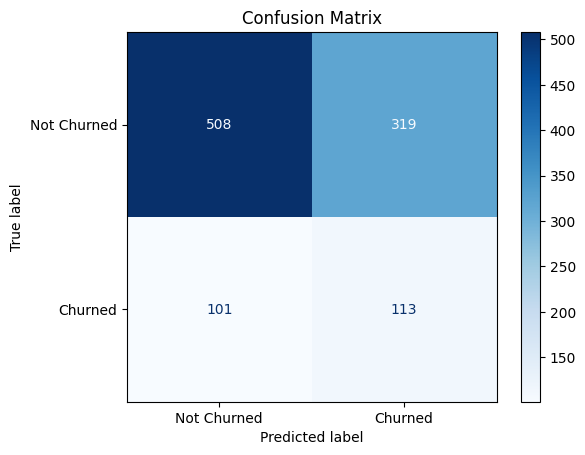

In [66]:


cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Churned', 'Churned'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [67]:
#calculating the roc and auc
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(roc_auc)

0.6068946422719207


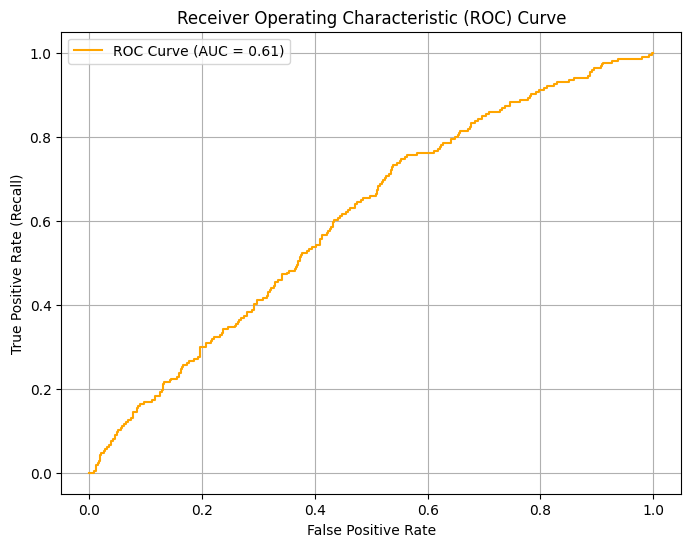

In [68]:
#Visualizing the evaluation

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {roc_auc:.2f})')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#calculating the feature importance
importances = model.feature_importances_
features = X_train.columns
print(importances)

In [ ]:
pd.Series(importances, index = features).sort_values(ascending=True).plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.xlabel("features")
plt.ylabel("Feature Importance ")
plt.grid(True)
plt.show()